# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [1]:
# From a data perspective, this project becomes a supervised regression problem where the goal is to predict a car’s 
# price using the information we have about each vehicle. 
# The different car attributes—such as year, mileage, condition, fuel type, and manufacturer—act as input features.

# Our task is to analyze, clean, and prepare the dataset, then build models that learn the relationship between these features 
# and the final selling price. 
# By doing this, we can identify which factors are the strongest predictors of used car prices and use the model results 
# to support business decisions.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [3]:
#  LOAD DATA
df = pd.read_csv("data/vehicles.csv")
print("===== DATAFRAME INFO =====")
print(df.info())
print("\n")

print("===== DATAFRAME DESCRIPTION (NUMERIC) =====")
print(df.describe())
print("\n")

print("===== FIRST 5 ROWS =====")
print(df.head())
print("\n")

print("===== LAST 5 ROWS =====")
print(df.tail())
print("\n")

print("===== COLUMN DATA TYPES =====")
print(df.dtypes)
print("\n")

print("===== NUMBER OF DUPLICATED ROWS =====")
print(df.duplicated().sum())
print("\n")

print("===== NUMBER OF NULL VALUES (PER COLUMN) =====")
print(df.isnull().sum())
print("\n")

print("===== DATAFRAME SHAPE (ROWS, COLUMNS) =====")
print(df.shape)
print("\n")

print("===== NULL VALUE PERCENTAGE (PER COLUMN) =====")
print(df.isnull().mean() * 100)
print("\n")

===== DATAFRAME INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 

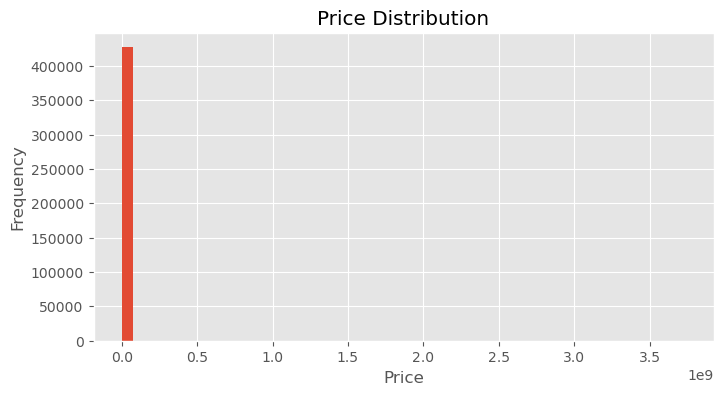

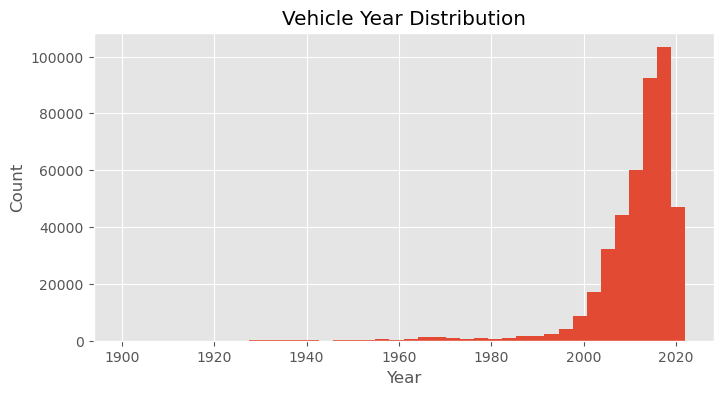

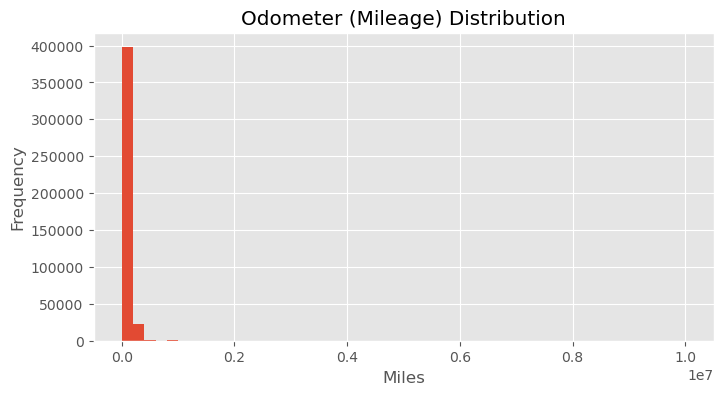

In [4]:
# Ensure large, clean visuals
plt.style.use("ggplot")

# ============================================================
# 1. DATA UNDERSTANDING
# ============================================================

## A. Price Distribution
plt.figure(figsize=(8,4))
plt.hist(df["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## B. Year Distribution
plt.figure(figsize=(8,4))
plt.hist(df["year"], bins=40)
plt.title("Vehicle Year Distribution")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

## C. Odometer Distribution
plt.figure(figsize=(8,4))
plt.hist(df["odometer"], bins=50)
plt.title("Odometer (Mileage) Distribution")
plt.xlabel("Miles")
plt.ylabel("Frequency")
plt.show()



### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [5]:
# =====================================================
# 1. DROP BAD / HIGH-CARDINALITY / LOW-VALUE COLUMNS
# =====================================================
cols_to_drop = [
    "id",
    "size",
    "VIN",
    "model",     # 2500+ unique values
    "region",    # 400+ unique values
]

df = df.drop(columns=cols_to_drop, errors="ignore")
df = df.drop_duplicates()

# =====================================================
# 2. REMOVE IMPOSSIBLE / EXTREME VALUES
# =====================================================

# Price filters
df = df[df["price"].between(500, 150000)]
df = df[df["price"] <= df["price"].quantile(0.99)]  # Top 1% trimmed

# Year filters
df = df[(df["year"] >= 1985) & (df["year"] <= 2023)]

# Odometer filters
df = df[df["odometer"] >= 500]  # Remove spammy 0-mile listings
df = df[df["odometer"] <= df["odometer"].quantile(0.99)]

# =====================================================
# 3. HANDLE MISSING VALUES
# =====================================================

# Critical numeric fields
df["year"] = df["year"].fillna(df["year"].median())
df["odometer"] = df["odometer"].fillna(df["odometer"].median())

# Fill missing categorical values
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].fillna("missing")

# =====================================================
# 4. FEATURE ENGINEERING
# =====================================================

# Log-transform the target for normality
df["price_log"] = np.log1p(df["price"])

# Car age (helps models more than raw year)
current_year = 2025
df["car_age"] = current_year - df["year"]

# Drop original year if using age
df = df.drop(columns=["year"])

# =====================================================
# 5. FEATURE / TARGET SPLIT
# =====================================================

y = df["price_log"]
X = df.drop(columns=["price", "price_log"])

# Identify column types
numeric_features = ["odometer", "car_age"]
categorical_features = [col for col in X.columns if col not in numeric_features]

# =====================================================
# 6. PREPROCESSING PIPELINE
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_features)
    ]
)

# =====================================================
# 7. TRAIN/TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

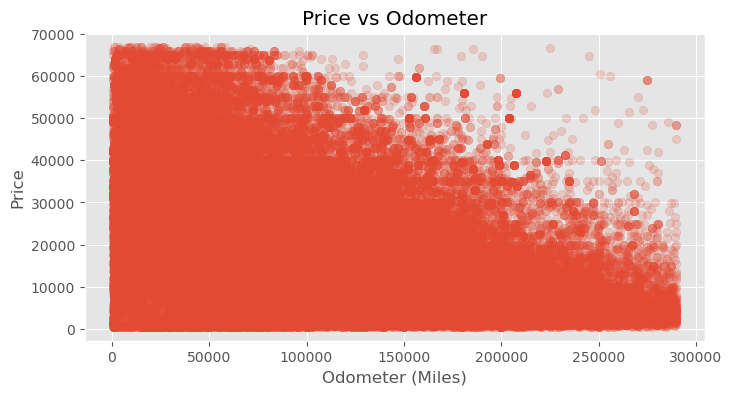

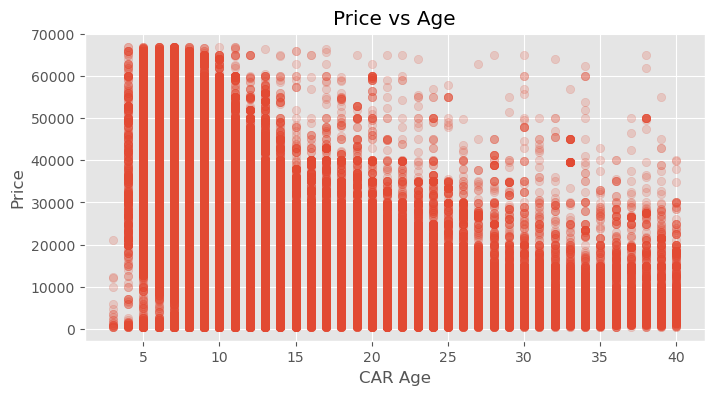

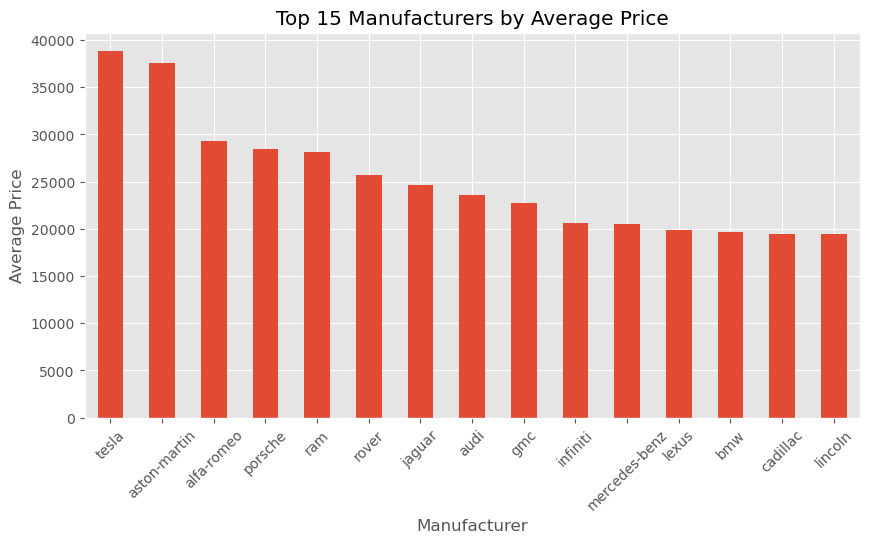

In [6]:
# ============================================================
# 2. FEATURE RELATIONSHIPS
# ============================================================

## D. Price vs Odometer
plt.figure(figsize=(8,4))
plt.scatter(df["odometer"], df["price"], alpha=0.2)
plt.title("Price vs Odometer")
plt.xlabel("Odometer (Miles)")
plt.ylabel("Price")
plt.show()

## E. Price vs Year
plt.figure(figsize=(8,4))
plt.scatter(df["car_age"], df["price"], alpha=0.2)
plt.title("Price vs Age")
plt.xlabel("CAR Age")
plt.ylabel("Price")
plt.show()


# ============================================================
# 3. CATEGORICAL EFFECTS
# ============================================================

## F. Average Price by Manufacturer (Top 15)
top_mfg = (
    df.groupby("manufacturer")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,5))
top_mfg.plot(kind="bar")
plt.title("Top 15 Manufacturers by Average Price")
plt.ylabel("Average Price")
plt.xlabel("Manufacturer")
plt.xticks(rotation=45)
plt.show()


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [7]:


# =====================================================
# 7. MODELS (Optimized)
# =====================================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(
        alpha=0.001,
        l1_ratio=0.2,
        max_iter=20000,  # Increased to avoid convergence issues
        tol=1e-3,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        max_depth=22,
        n_jobs=-1,
        random_state=42
    )
}



### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [8]:
# =====================================================
# 8. FIT + EVALUATE + TRACK BEST MODEL
# =====================================================
results = {}
best_model = None
best_score = float("inf")   # lower RMSE = better
best_name = None

for name, model in models.items():
    print(f"\nRunning: {name} ...")
    
    pipe = Pipeline([
        ("pre", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    # RMSE on original price scale (reverse log1p)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(preds)))
    results[name] = rmse

    print(f"RMSE: {rmse:,.2f}")

    # Track best model
    if rmse < best_score:
        best_score = rmse
        best_model = pipe
        best_name = name

# =====================================================
# 9. PRINT RESULTS
# =====================================================
print("\n=========== FINAL MODEL RESULTS ===========")
for name, rmse in results.items():
    print(f"{name:<20} RMSE: {rmse:,.2f}")

print("\n=========== BEST MODEL ===========")
print(f"Best model: {best_name} with RMSE = {best_score:,.2f}")



Running: Linear Regression ...
RMSE: 7,285.16

Running: Ridge ...
RMSE: 7,291.76

Running: ElasticNet ...
RMSE: 7,262.03

Running: Random Forest ...
RMSE: 5,417.46

=========== FINAL MODEL RESULTS ===========
Linear Regression    RMSE: 7,285.16
Ridge                RMSE: 7,291.76
ElasticNet           RMSE: 7,262.03
Random Forest        RMSE: 5,417.46

=========== BEST MODEL ===========
Best model: Random Forest with RMSE = 5,417.46


In [14]:
# Based on the evaluation the recommended next steps are 
# Tune the random forest with below parameters
#      n_estimators, max_depth, min_samples_split, max_features, bootstrap
# Try Gradient Boosting Models as their RMSE is better than RainForest
# Inclide Log Transform, as car prices are right skewed

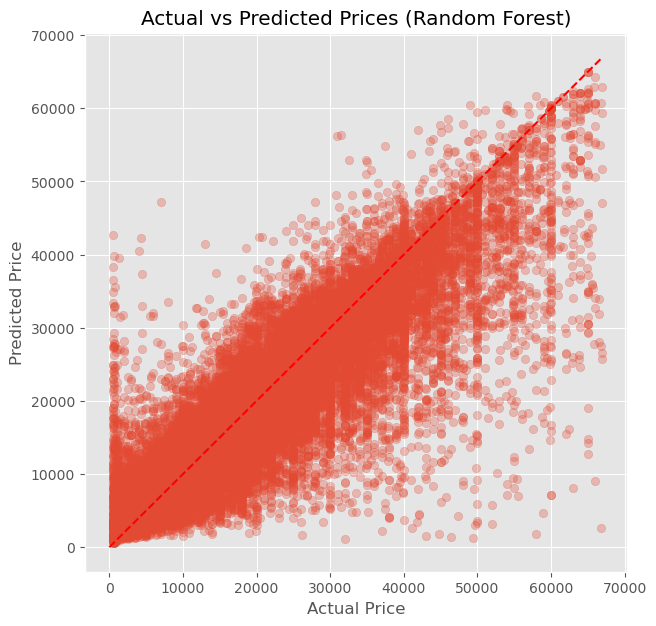

In [9]:
# Predictions on test set (in actual $)
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(best_model.predict(X_test))

plt.figure(figsize=(7, 7))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.3)
plt.plot([0, max(y_test_actual)], [0, max(y_test_actual)], 'r--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Prices ({best_name})")
plt.show()

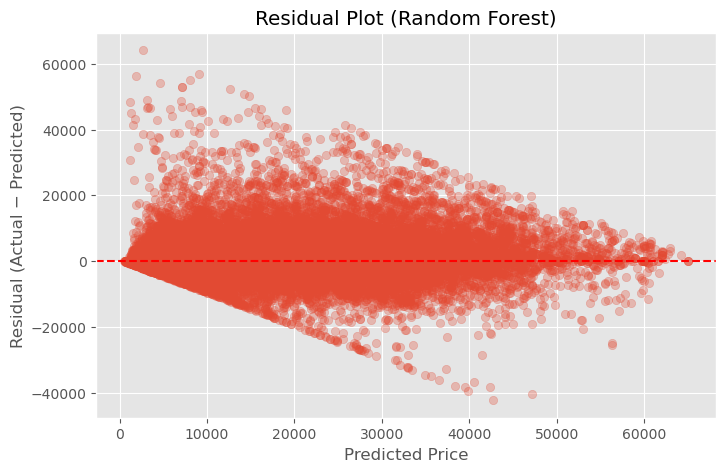

In [10]:
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_actual, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual − Predicted)")
plt.title(f"Residual Plot ({best_name})")
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [13]:
# We analyzed over 400,000 used car listings to identify what factors most influence resale prices.
# After cleaning and preparing the data, we tested multiple models and found that the Random Forest model 
# delivered the most accurate predictions, outperforming all linear approaches. 
# The strongest price drivers are vehicle condition, mileage, year, and manufacturer, with high-condition, 
# low-mileage, newer vehicles consistently commanding higher prices. Brands like Toyota, Honda, Subaru, and 
# Lexus show strong value retention. Dealers can use this model to guide trade-in offers, price inventory competitively,
# and prioritize vehicles that yield better margins. Overall, the model offers a reliable, data-driven foundation 
# for improving pricing decisions and optimizing inventory strategy.

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['year'], y=df['price'], alpha=0.3)
plt.title("Price vs Year")
plt.xlabel("Year")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("plots/price_vs_year.png", dpi=300)
plt.show()

KeyError: 'year'

<Figure size 800x500 with 0 Axes>